### Exercise-Book

Work provided by my supervisors

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
t = np.arange(0, 100)
x_t = np.sin(0.1 * np.pi * t)

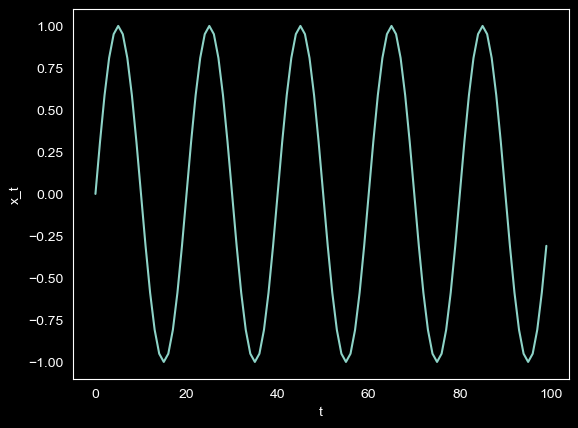

In [16]:
plt.plot(t, x_t)
plt.xlabel("t")
plt.ylabel("x_t")
plt.grid()
plt.show()

In [17]:
ε1,ε2,ε3,ε4  = 0.05, 0.25, 0.5, 0.78
shape = (len(x_t), len(x_t))
R1, R2, R3, R4 = [np.zeros(shape, dtype=bool) for _ in range(4)]
#R1

In [18]:
for i in range(len(x_t)) :
    for j in range(len(x_t)) :
        Δ = abs(x_t[i] - x_t[j])
        R1[i,j] = Δ <= ε1
        R2[i,j] = Δ <= ε2
        R3[i,j] = Δ <= ε3
        R4[i,j] = Δ <= ε4

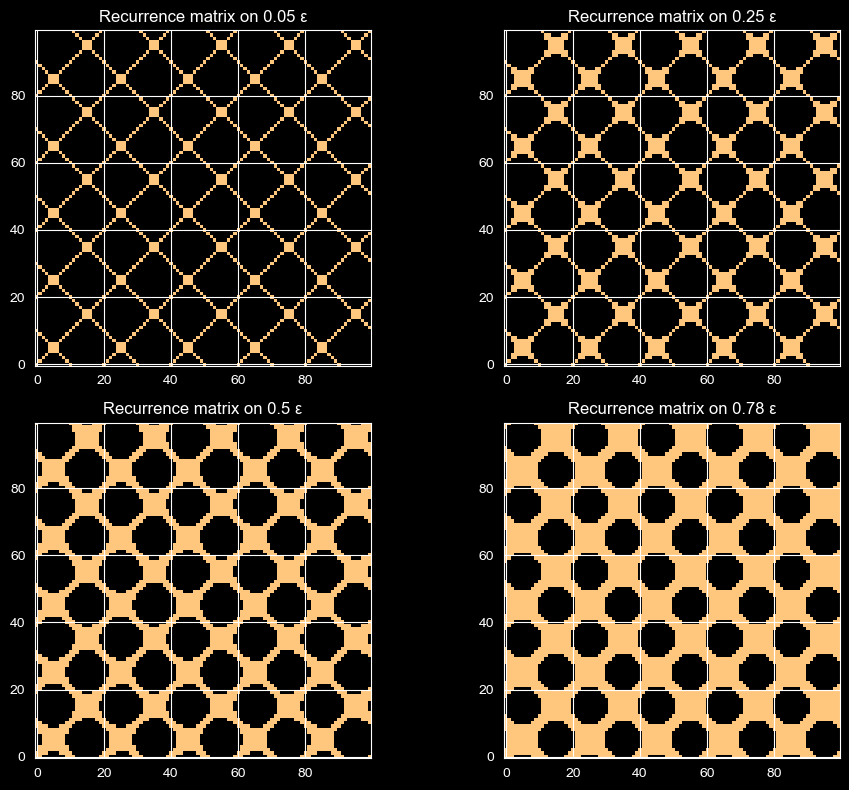

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0,0].imshow(R1, cmap="copper", origin="lower", interpolation="nearest")
ax[0,1].imshow(R2, cmap="copper", origin="lower", interpolation="nearest")
ax[1,0].imshow(R3, cmap="copper", origin="lower", interpolation="nearest")
ax[1,1].imshow(R4, cmap="copper", origin="lower", interpolation="nearest")

ax[0,0].set_title("Recurrence matrix on 0.05 ε")
ax[0,1].set_title("Recurrence matrix on 0.25 ε")
ax[1,0].set_title("Recurrence matrix on 0.5 ε")
ax[1,1].set_title("Recurrence matrix on 0.78 ε")

#fig1.colorbar(im, ax=ax1, label="Distance")
plt.tight_layout()
plt.show()

### Observations

Smaller ε -> reccurence rate shrinks
Larger ε -> reccurence rate grows

It is only natural that such values of ε will lead to such results. What is important is determining how to choose an ε s.t. results aren't forced in either direction : we want the recurrence plot to capture enough information, while filtering out the noise.

In [46]:
# Randomly chosen values, not sure if they are good/bad
m = 4
t = 2

shape = (len(x_t - (m - 1) * t), len(x_t - (m - 1) * t))
R1, R2, R3, R4 = [np.zeros(shape, dtype=bool) for _ in range(4)]

windows = np.lib.stride_tricks.sliding_window_view(x_t, (m - 1) * t + 1)
vectors = windows[:, ::t] # keep slices with a delay of t

shape = (len(vectors), len(vectors))
R1, R2, R3, R4 = [np.zeros(shape, dtype=bool) for _ in range(4)]
#windows

In [47]:
#vectors

In [48]:
for i in range(len(vectors)):
    for j in range(len(vectors)):

        # Use Euc Distance
        Δ = (vectors[i] - vectors[j]) ** 2
        Δ = np.sqrt(np.sum(Δ))

        R1[i,j] = Δ <= ε1
        R2[i,j] = Δ <= ε2
        R3[i,j] = Δ <= ε3
        R4[i,j] = Δ <= ε4

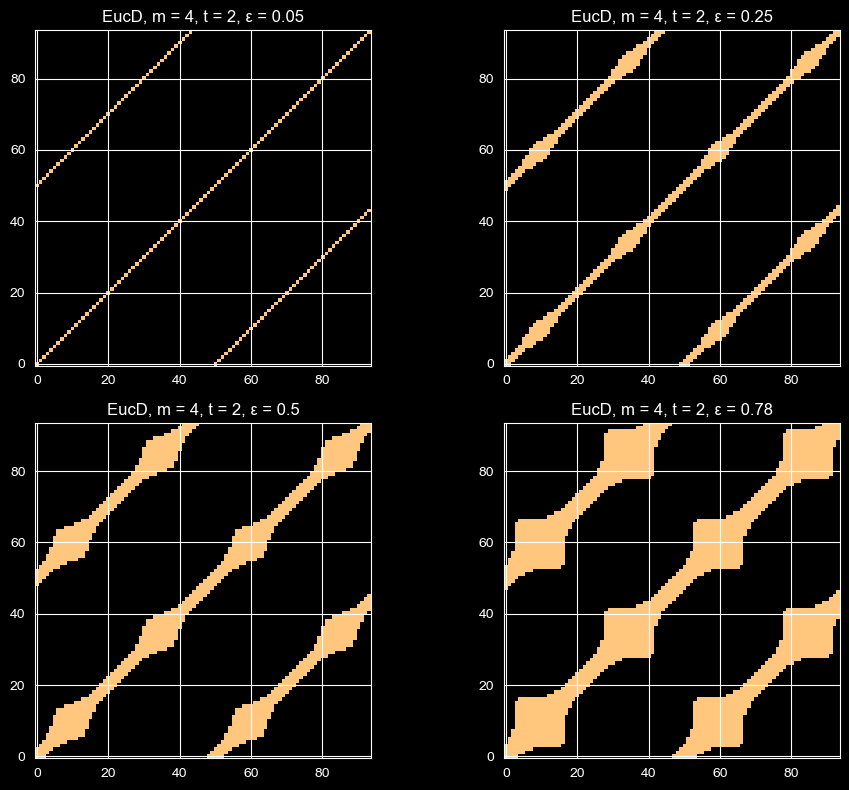

In [49]:
fig1, ax1 = plt.subplots(2, 2, figsize=(10, 8))
ax1[0,0].imshow(R1, cmap="copper", origin="lower", interpolation="nearest")
ax1[0,1].imshow(R2, cmap="copper", origin="lower", interpolation="nearest")
ax1[1,0].imshow(R3, cmap="copper", origin="lower", interpolation="nearest")
ax1[1,1].imshow(R4, cmap="copper", origin="lower", interpolation="nearest")

ax1[0,0].set_title("EucD, m = 4, t = 2, ε = 0.05")
ax1[0,1].set_title("EucD, m = 4, t = 2, ε = 0.25")
ax1[1,0].set_title("EucD, m = 4, t = 2, ε = 0.5")
ax1[1,1].set_title("EucD, m = 4, t = 2, ε = 0.78")

#fig1.colorbar(im, ax=ax1, label="Distance")
plt.tight_layout()
plt.show()

### Randomness

In [42]:
t = np.arange(0, 100)
x_t = np.sin(0.04 * np.pi * t)

rng = np.random.default_rng(seed=42)
noise_strength = 0.25
ε = 0.25

# Noise
added_noise = rng.normal(loc=0.0, scale=noise_strength, size=len(t))
x_noisy = x_t + added_noise
x_random = rng.normal(loc=0.0, scale=noise_strength, size=len(t))

In [43]:
R = np.zeros(shape, dtype=bool)
R_noisy = np.zeros(shape, dtype=bool)
R_random = np.zeros(shape, dtype=bool)

for i in range(len(t)):
   for j in range(len(t)):

       Δ = abs(x_t[i] - x_t[j])
       Δ_noisy = abs(x_noisy[i] - x_noisy[j])
       Δ_random = abs(x_random[i] - x_random[j])

       R[i, j] = Δ <= ε
       R_noisy[i, j] = Δ_noisy <= ε
       R_random[i, j] = Δ_random <= ε

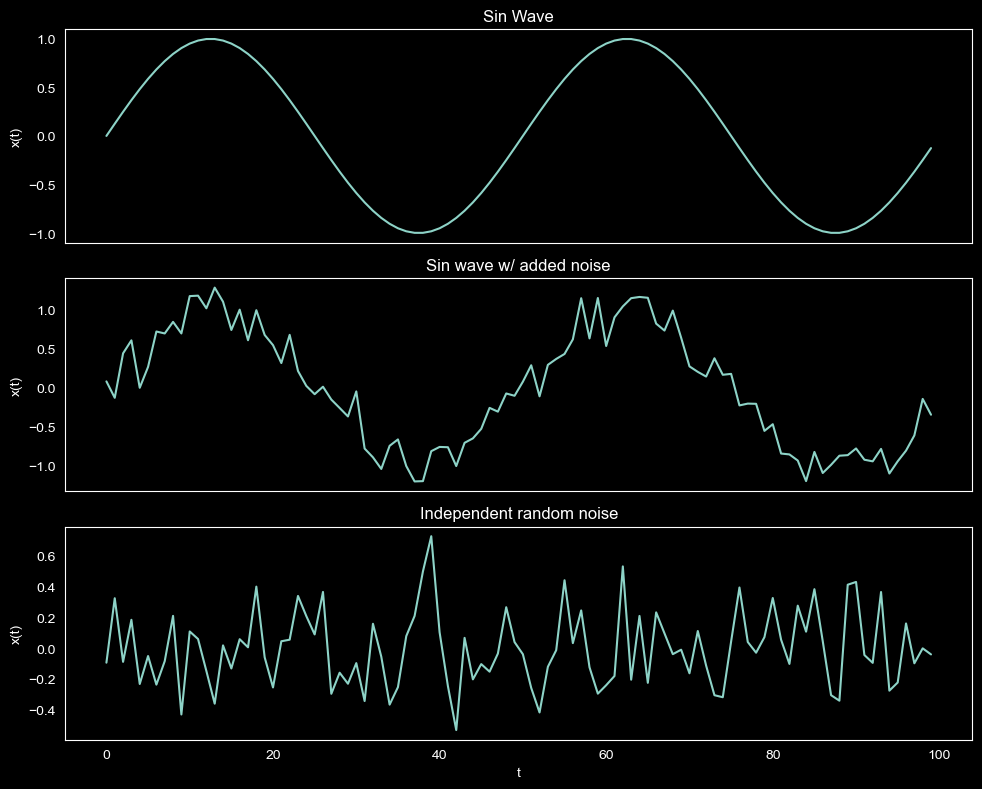

In [44]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, x_t)
ax[0].set_title("Sin Wave")
ax[0].set_ylabel("x(t)")
ax[0].grid()

ax[1].plot(t, x_noisy)
ax[1].set_title("Sin wave w/ added noise")
ax[1].set_ylabel("x(t)")
ax[1].grid()

ax[2].plot(t, x_random)
ax[2].set_title("Independent random noise")
ax[2].set_xlabel("t")
ax[2].set_ylabel("x(t)")
ax[2].grid()

plt.tight_layout()
plt.show()

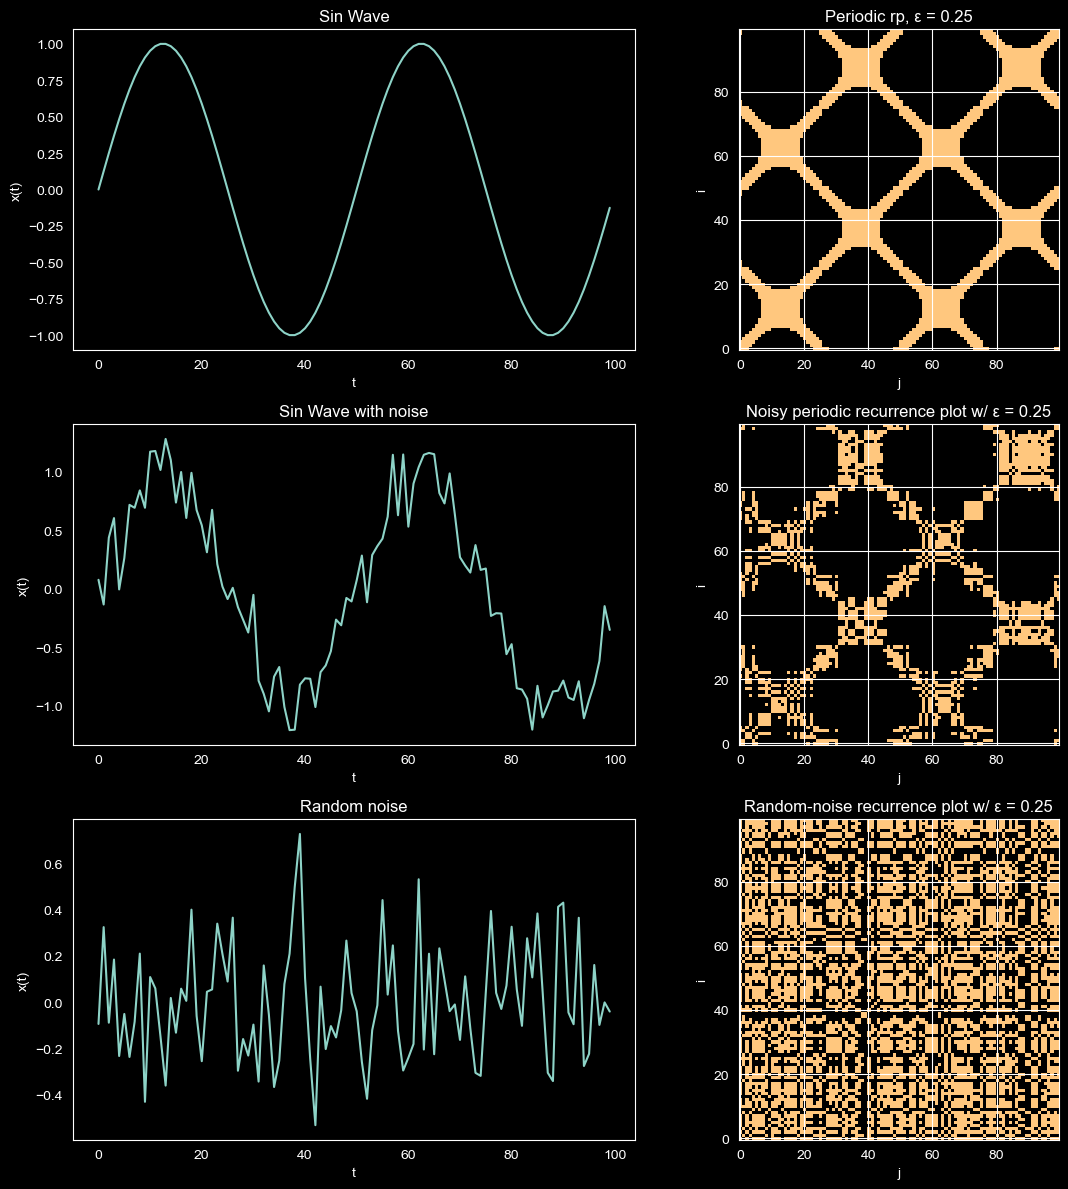

In [45]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))

ax[0, 0].plot(t, x_t)
ax[0, 0].set_title("Sin Wave")
ax[0, 0].set_xlabel("t")
ax[0, 0].set_ylabel("x(t)")
ax[0, 0].grid()

ax[0, 1].imshow(R, cmap="copper", origin="lower", interpolation="nearest")
ax[0, 1].set_title(f"Periodic rp, ε = {ε}")
ax[0, 1].set_xlabel("j")
ax[0, 1].set_ylabel("i")

# Sin wave w/ noise
ax[1, 0].plot(t, x_noisy)
ax[1, 0].set_title(f"Sin Wave with noise")
ax[1, 0].set_xlabel("t")
ax[1, 0].set_ylabel("x(t)")
ax[1, 0].grid()

ax[1, 1].imshow(R_noisy, cmap="copper", origin="lower", interpolation="nearest")
ax[1, 1].set_title(f"Noisy periodic recurrence plot w/ ε = {ε}")
ax[1, 1].set_xlabel("j")
ax[1, 1].set_ylabel("i")

# Random noise
ax[2, 0].plot(t, x_random)
ax[2, 0].set_title("Random noise")
ax[2, 0].set_xlabel("t")
ax[2, 0].set_ylabel("x(t)")
ax[2, 0].grid()

ax[2, 1].imshow(R_random, cmap="copper", origin="lower", interpolation="nearest")
ax[2, 1].set_title(f"Random-noise recurrence plot w/ ε = {ε}")
ax[2, 1].set_xlabel("j")
ax[2, 1].set_ylabel("i")

plt.tight_layout()
plt.show()